In [1]:
# ------------------------------
# STEP 0: Install YOLOv8
# ------------------------------
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.0 MB/s eta 0:00:00


In [1]:
# ------------------------------
# STEP 1: Upload & Unzip Dataset
# ------------------------------
from google.colab import files
import zipfile, os, yaml
uploaded = files.upload()  # upload Blind_Path_Damage_v1i_yolov8.zip
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("✅ Extracted successfully")

for split in ["train", "valid", "test"]:
    img_path = f"dataset/{split}/images"
    if os.path.exists(img_path):
        print(f"{split}: {len(os.listdir(img_path))} images")
    else:
        print(f"⚠️ {split}/images not found!")

Saving Blind Path Damage.v1i.yolov8.zip to Blind Path Damage.v1i.yolov8.zip
✅ Extracted successfully
train: 1880 images
valid: 248 images
test: 124 images


In [4]:
# ------------------------------
# STEP 2: Create data.yaml
# ------------------------------
yaml_path = "data.yaml"

data_yaml_content = {
    'train': 'dataset/train/images',
    'val':   'dataset/valid/images',
    'test':  'dataset/test/images',
    'nc':    3,
    'names': ['minor_damage', 'normal_path', 'severe_damage']
}
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False)

print(f"✅ data.yaml created")
print(f"Classes ({data_yaml_content['nc']}):", data_yaml_content['names'])

✅ data.yaml created
Classes (3): ['minor_damage', 'normal_path', 'severe_damage']


In [6]:
# ------------------------------
# STEP 3: Train YOLOv8
# ------------------------------
!pip install ultralytics --quiet

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=yaml_path,
    epochs=50,
    batch=16,
    imgsz=640,
    project="path_damage",
    name="yolov8_damage_detector",
    exist_ok=True
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freez

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bb81c463470>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [8]:
import os

# ------------------------------
# STEP 4: Load Best Weights
# ------------------------------
best_model  = YOLO(os.path.join("runs", "detect", "path_damage", "yolov8_damage_detector", "weights", "best.pt"))
class_names = data_yaml_content['names']
print("✅ Model loaded. Classes:", class_names)

✅ Model loaded. Classes: ['minor_damage', 'normal_path', 'severe_damage']


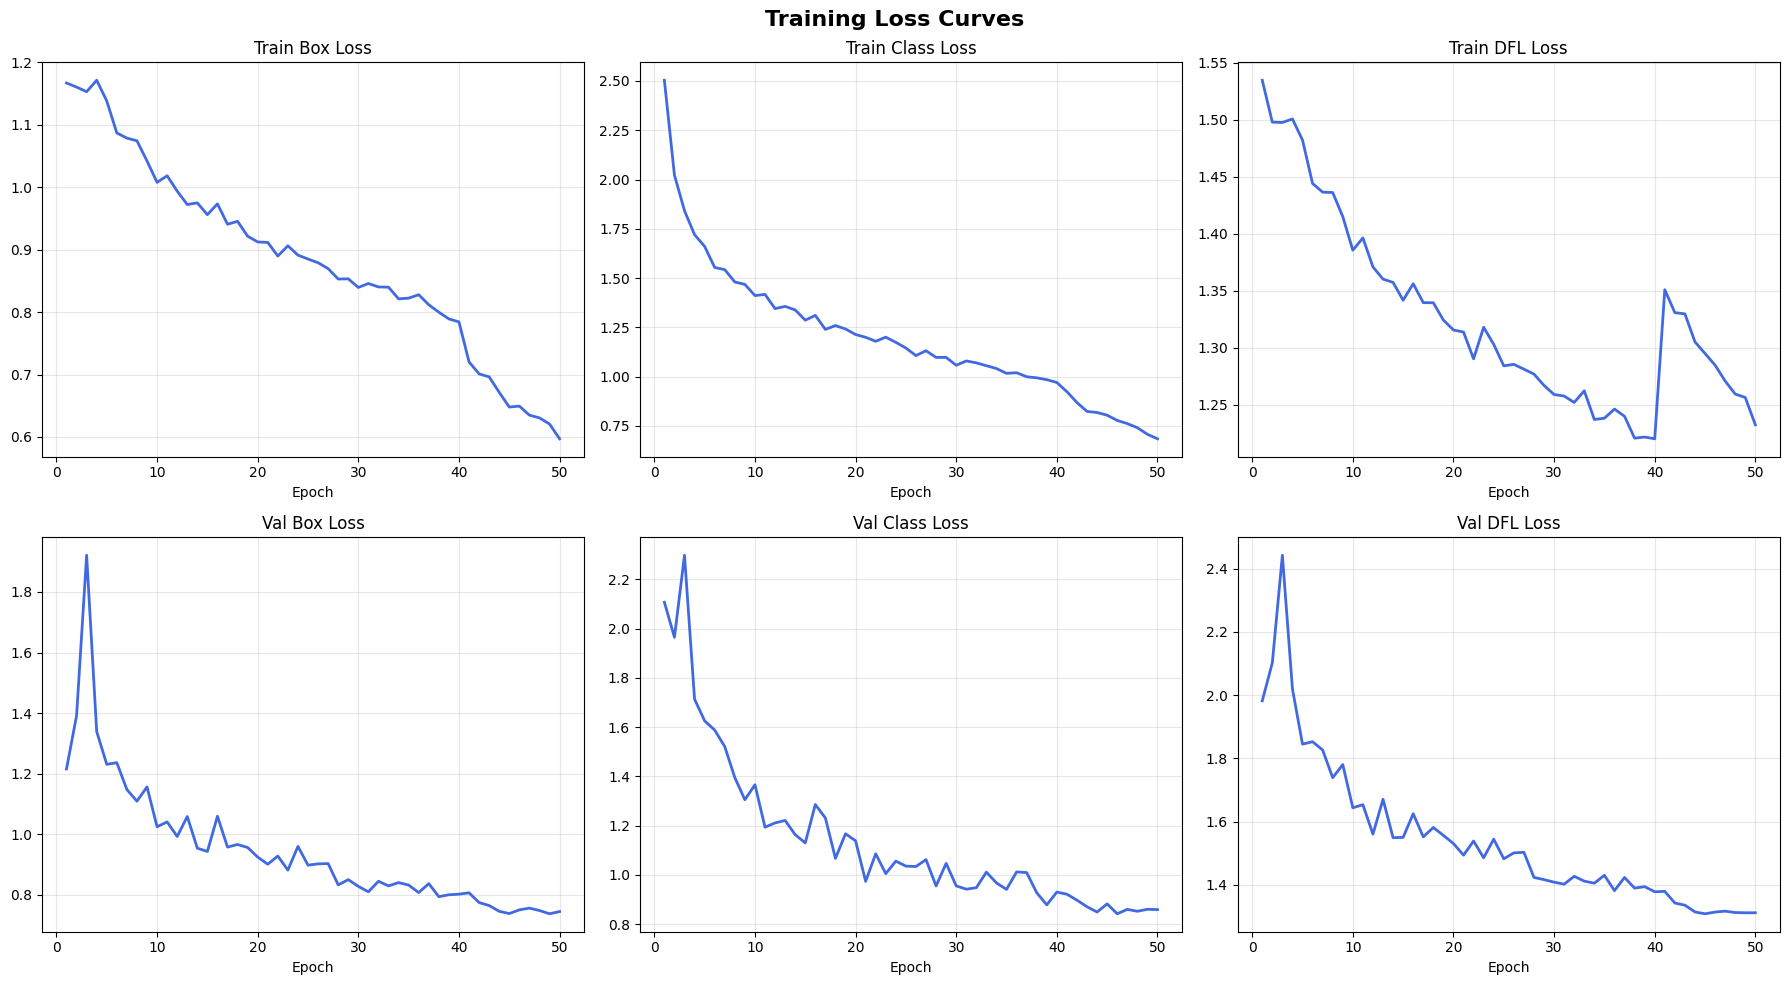

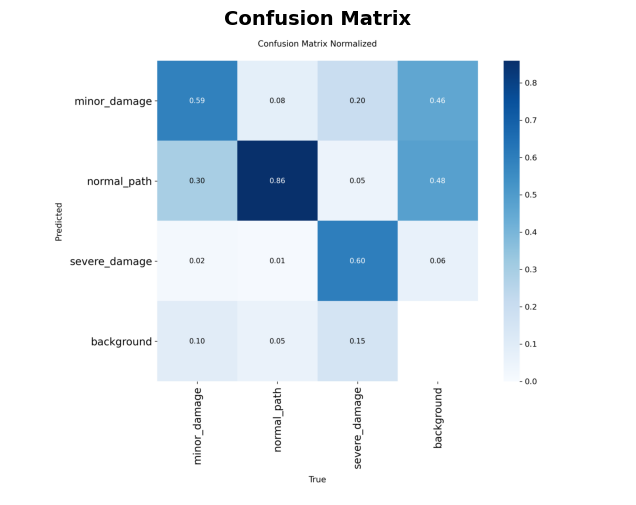

In [10]:
# ------------------------------
# STEP 4.5: Loss Curves & Confusion Matrix
# ------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

results_dir = Path("runs/detect/path_damage/yolov8_damage_detector")

# Loss Curves
csv_path = results_dir / "results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training Loss Curves", fontsize=16, fontweight='bold')

plots = [
    ("train/box_loss", "Train Box Loss",   axes[0][0]),
    ("train/cls_loss", "Train Class Loss", axes[0][1]),
    ("train/dfl_loss", "Train DFL Loss",   axes[0][2]),
    ("val/box_loss",   "Val Box Loss",     axes[1][0]),
    ("val/cls_loss",   "Val Class Loss",   axes[1][1]),
    ("val/dfl_loss",   "Val DFL Loss",     axes[1][2]),
]

for col, title, ax in plots:
    if col in df.columns:
        ax.plot(df["epoch"], df[col], linewidth=2, color="royalblue")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f"{title} (not found)", fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.show()

# Confusion Matrix
conf_matrix_path = results_dir / "confusion_matrix_normalized.png"
if not conf_matrix_path.exists():
    conf_matrix_path = results_dir / "confusion_matrix.png"

if conf_matrix_path.exists():
    img = mpimg.imread(conf_matrix_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.show()
else:
    print("⚠️ Confusion matrix not found.")

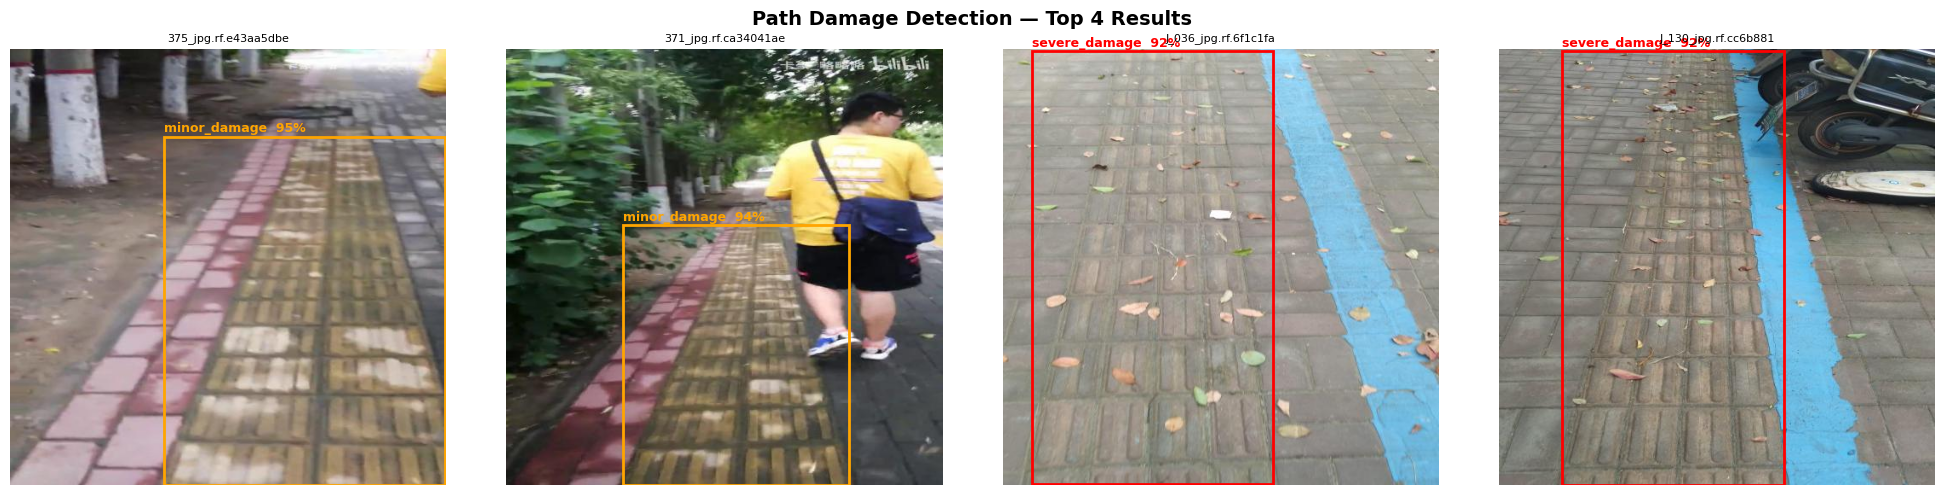

In [11]:
# ------------------------------
# STEP 5: Test on Top 4 Images
# ------------------------------
import matplotlib.patches as patches
from PIL import Image
import numpy as np

test_img_dir = "dataset/test/images"
all_images   = os.listdir(test_img_dir)

# Pick 4 images with highest confidence detections
scored = []
for img_name in all_images:
    test_img_path = os.path.join(test_img_dir, img_name)
    results = best_model.predict(test_img_path, conf=0.25, verbose=False)
    if len(results[0].boxes) > 0:
        top_conf = float(results[0].boxes.conf.max())
        scored.append((top_conf, img_name))

scored.sort(reverse=True)
test_images = [img_name for _, img_name in scored[:4]]

COLORS = {
    'minor_damage':  'orange',
    'normal_path':   'green',
    'severe_damage': 'red',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Path Damage Detection — Top 4 Results", fontsize=14, fontweight='bold')

for ax, img_name in zip(axes, test_images):
    test_img_path = os.path.join(test_img_dir, img_name)
    results       = best_model.predict(test_img_path, conf=0.25, verbose=False)

    img = Image.open(test_img_path)
    ax.imshow(img)

    for box in results[0].boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls   = int(box.cls[0])
        conf  = float(box.conf[0])
        label = f"{class_names[cls]}  {conf*100:.0f}%"
        color = COLORS.get(class_names[cls], 'red')

        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, label, color=color, fontsize=9, fontweight='bold')

    ax.axis("off")
    ax.set_title(img_name[:20], fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
# ------------------------------
# STEP 6: Export Model
# ------------------------------
best_model.export(format="onnx")
best_model.export(format="torchscript")
print("✅ Models exported.")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/path_damage/yolov8_damage_detector/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 247ms
Prepared 4 packages in 5.97s
Installed 4 packages in 330ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 7.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 8.6s, save

In [14]:
# ------------------------------
# STEP 7: Download Model
# ------------------------------
import shutil
from google.colab import files # Ensure files is imported if not already

shutil.copy(
    "runs/detect/path_damage/yolov8_damage_detector/weights/best.pt",
    "blind_path_damage_best.pt"
)
files.download("blind_path_damage_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>